# NVDA — leaderboard and interval calibration

Two questions about every forecaster in the registry, kept separate on purpose:

1. **Is it accurate?** — the CRPS leaderboard.
2. **Is it honest?** — the coverage-vs-sharpness chart. A forecaster can score well on
   average while claiming far more certainty than it has, and the leaderboard alone will
   not show it.

Everything here reads the committed prediction YAMLs by **globbing the registry**, so a
predictor appears in both views the moment its results land in
`data/predictions/<spec_id>/`. Re-running this notebook is the whole update path when the
news-grounded and adaptive agents arrive — there is no code to change.

> Run from the repository root, after `uv run python scripts/fetch_nvda.py` has populated
> the price cache and `uv run python -m ai_stocks_forecasting.baselines` has produced the
> baseline predictions.

In [1]:
import pandas as pd
from ai_stocks_forecasting.analysis import leaderboard_with_uncertainty, per_horizon_crps
from ai_stocks_forecasting.charts import coverage_sharpness, coverage_sharpness_table, load_scored_frame
from ai_stocks_forecasting.data import build_nvda_service


SPEC_ID = "nvda_backtest"  # swap to "nvda_eval" for the protected 2026 window

pd.set_option("display.width", 160)

data_service = build_nvda_service()
frame = load_scored_frame(SPEC_ID, data_service)

print(f"{SPEC_ID}: {len(frame)} scored predictions across {frame['predictor'].nunique()} predictors")
print(f"predictors: {', '.join(sorted(frame['predictor'].unique()))}")

nvda_backtest: 290 scored predictions across 2 predictors
predictors: AutoARIMA, Naive (last value)


## 1. Leaderboard

CRPS in USD/share, lower is better. The `se` column is the lens for *"is this lead real?"* —
when the gap between two predictors is small next to their standard errors, the ranking is
not meaningful.

**A caveat that applies to the naive row specifically.** `LastValuePredictor` emits a point
mass — every quantile equals the last close — so its CRPS reduces exactly to mean absolute
error. It is not being scored as a distribution at all. Any predictor that *does* emit
intervals is being held to a stricter standard on this table.

In [2]:
leaderboard_with_uncertainty(frame).round(3)

,mean_crps,se,n,family
predictor,,,,
AutoARIMA,10.025,0.787,145,Numerical ML
Naive (last value),10.665,0.625,145,Baseline


In [3]:
per_horizon_crps(frame).round(2)

,h=5d,h=10d,h=21d,All
predictor,,,,
AutoARIMA,7.45,8.79,13.54,10.03
Naive (last value),8.23,10.09,13.44,10.67


## 2. Coverage vs sharpness

An 80% prediction interval promises to contain the outcome 80% of the time. This chart plots
what each predictor actually delivered against how wide an interval it needed to deliver it.

- **On the dashed line** — honest. The further *left* on the line, the more useful: same
  honesty, narrower interval.
- **Below the line** — overconfident. The interval is too narrow; the forecaster is claiming
  certainty it does not have.
- **Above the line** — under-confident. Correct, but too vague to act on.

Horizons are faceted rather than pooled, because interval width is in dollars and is not
comparable across them — a \\$12 interval at 21 days is not "worse" than a \\$4 one at 5 days,
it is answering a harder question.

The table is printed first and is not decoration: it is the accessible view of the same
numbers, and the thing to read when two points overlap.

In [4]:
coverage_sharpness_table(frame)

coverage_80  mean_width  mean_crps   n  miscalibration
family       predictor          horizon                                                        
Baseline     Naive (last value) 5               0.00        0.00       8.23  47           -80.0
                                10              0.00        0.00      10.09  47           -80.0
                                21              0.00        0.00      13.44  51           -80.0
Numerical ML AutoARIMA          5              10.64        3.91       7.45  47           -69.4
                                10             17.02        7.02       8.79  47           -63.0
                                21             15.69       12.74      13.54  51           -64.3

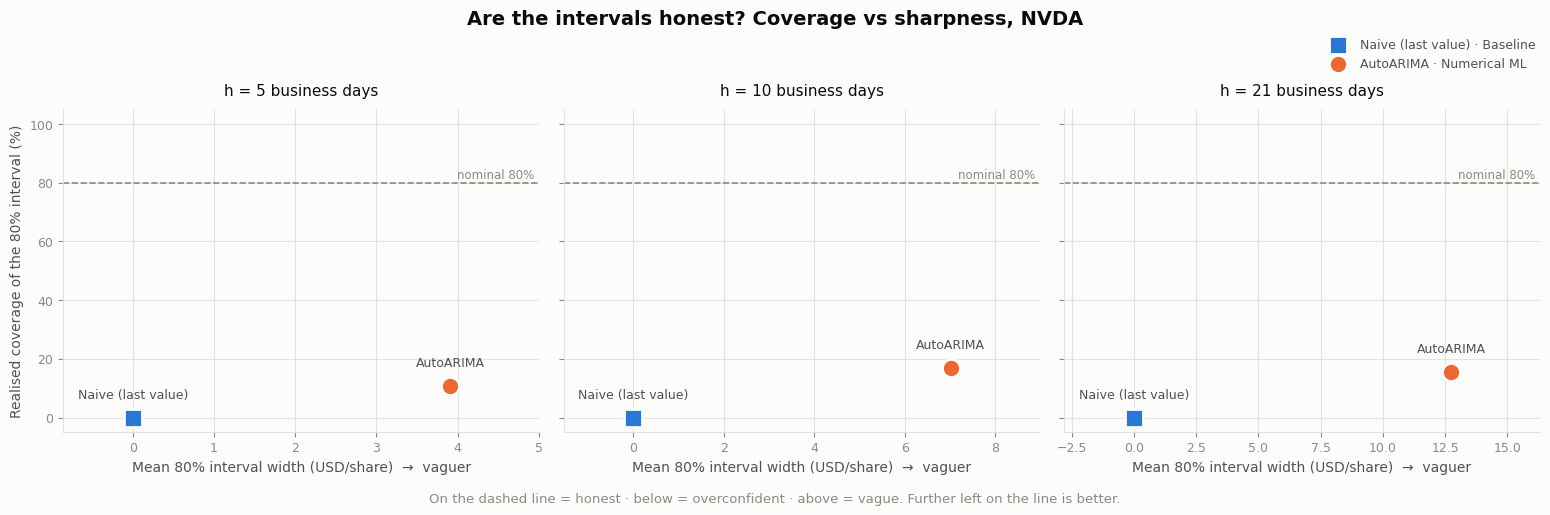

In [5]:
fig, axes = coverage_sharpness(frame)

### Reading the current picture

Both numerical baselines sit in the bottom strip, far below the line:

- **Naive** is at the origin — zero-width intervals, therefore zero coverage. It is maximally
  sharp and maximally dishonest, the degenerate corner of the plot.
- **AutoARIMA** covers 10.6% / 17.0% / 15.7% against a nominal 80%, with intervals roughly
  4.5x to 7x too narrow for the errors it actually makes.

**The trap this chart exists to prevent.** Because the numerical floor is this overconfident,
an agent with honestly wide intervals will beat it on coverage almost for free — and that
would be a hollow win, not evidence the agent knows anything. A forecaster can walk to the
dashed line by widening its intervals until they contain everything. The claim worth making
is *moving left along the line*: matching coverage at a **narrower** width, or improving CRPS,
which penalises vagueness and miscalibration together. Read this chart alongside the
leaderboard, never instead of it.

## 3. How this notebook grows

Nothing here is hard-coded to the two baselines.

| When | What to do |
|---|---|
| News-grounded agent predictions land | re-run — the agent appears in the aqua *LLM / Agent* family |
| Adaptive agent predictions land | re-run — a second marker shape within the same family |
| Scoring the protected 2026 window | set `SPEC_ID = "nvda_eval"` and re-run |

Colour encodes the predictor **family**, not the individual predictor, and marker shape
separates predictors within a family. That is deliberate: the categorical palette is only
validated for colourblind separation up to three series on a scatter, so a fourth hue would
fail the check, and tying colour to family rather than to rank means adding a predictor
never repaints the existing ones between phases.